# caesar2020cvpr

> Module to handle loading, preprocessing and postprocessing of the data from [NuScenes](https://www.nuscenes.org/) dataset.

In [ ]:
#| default_exp caesar2020cvpr

In [ ]:
#| export
from pathlib import Path
import json
import numpy as np
from torch.utils.data import Dataset
from pyquaternion import Quaternion
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.axes import Axes
from matplotlib.patches import Polygon

#### [nuscenes-devkit](https://github.com/nutonomy/nuscenes-devkit)

This is an adaptation of the code from the [nuscenes-devkit](https://github.com/nutonomy/nuscenes-devkit) as a [PyTorch Dataset](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).

### Colors
The colors used by NuScenes are defined in the [color_map.py](https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/utils/color_map.py) file and are used to visualize the data.

Here we define the colors used by NuScenes in a json file in the dataset folder. Create a file called `colors.json` in the dataset folder with the following content:

```json
{
  "noise": [0, 0, 0],
  "animal": [70, 130, 180],
  "human.pedestrian.adult": [0, 0, 230],
  "human.pedestrian.child": [135, 206, 235],
  "human.pedestrian.construction_worker": [100, 149, 237],
  "human.pedestrian.personal_mobility": [219, 112, 147],
  "human.pedestrian.police_officer": [0, 0, 128],
  "human.pedestrian.stroller": [240, 128, 128],
  "human.pedestrian.wheelchair": [138, 43, 226],
  "movable_object.barrier": [112, 128, 144],
  "movable_object.debris": [210, 105, 30],
  "movable_object.pushable_pullable": [105, 105, 105],
  "movable_object.trafficcone": [47, 79, 79],
  "static_object.bicycle_rack": [188, 143, 143],
  "vehicle.bicycle": [220, 20, 60],
  "vehicle.bus.bendy": [255, 127, 80],
  "vehicle.bus.rigid": [255, 69, 0],
  "vehicle.car": [255, 158, 0],
  "vehicle.construction": [233, 150, 70],
  "vehicle.emergency.ambulance": [255, 83, 0],
  "vehicle.emergency.police": [255, 215, 0],
  "vehicle.motorcycle": [255, 61, 99],
  "vehicle.trailer": [255, 140, 0],
  "vehicle.truck": [255, 99, 71],
  "flat.driveable_surface": [0, 207, 191],
  "flat.other": [175, 0, 75],
  "flat.sidewalk": [75, 0, 75],
  "flat.terrain": [112, 180, 60],
  "static.manmade": [222, 184, 135],
  "static.other": [255, 228, 196],
  "static.vegetation": [0, 175, 0],
  "vehicle.ego": [255, 240, 245]
}
```

## 🔎 About the nuScenes Dataset

The [nuScenes dataset](https://www.nuscenes.org/) is a large-scale autonomous driving dataset that contains:

* 1000 scenes collected in Boston and Singapore
* 3D LIDAR and RADAR data
* 6 RGB cameras
* IMU, GPS and compass data
* Rich annotations including 3D bounding boxes and semantic labels
* Much more!

The dataset is designed to support the development of perception, prediction, and planning algorithms for autonomous vehicles.

### Key Terminology

* **Scene**: A 20-second log of data, including all sensors, representing a driving sequence.
* **Sample**: A single timestamp within a scene. It corresponds to one "frame" of all sensors.
* **Sweep**: A single sensor's data capture. For LIDAR, this is a 360° point cloud frame, for cameras, it is a single image.

## 📁 Dataset Structure

Your code expects the following simplified structure:

```
nuscenes/
└── {version}/
    ├── sample_data.json
    ├── sample.json
    ├── lidarseg.json
    ├── sample_annotation.json
    ├── instance.json
    ├── category.json
    ├── ego_pose.json
    ├── calibrated_sensor.json
    ├── colors.json
    ├── lidarseg/
    │   └── {version}/
    │       └── {token}_lidarseg.bin
    └── sweeps/
        └── LIDAR_TOP/
            └── *.bin
        └── RADAR_{RADAR_POSITION}/
            └── *.pcd
        └── CAM_{CAM_POSITION}/
            └── *.jpg
```

## 📄 JSON File Explanations

The NuScenes dataset consists of several JSON files that describe the data structure and relationships between different components. Each file serves a specific purpose, such as defining samples, sweeps, annotations, and categories.
Let’s look at examples and their meaning:

---

### `sample.json`

Each `sample` represents a snapshot in time, containing data from all sensors (LIDAR, radar, cameras).

**Fields:**

* `token`: Unique ID of the sample.
* `timestamp`: Time in microseconds since epoch.
* `prev`: Token of the previous sample (empty if none).
* `next`: Token of the next sample (empty if none).
* `scene_token`: Links the sample to its scene.

---

### `sample_data.json`

Describes individual sensor data associated with a `sample`.

**Fields:**

* `token`: Unique ID for this sensor data.
* `sample_token`: References the parent sample.
* `ego_pose_token`: References the ego vehicle’s pose at this time.
* `calibrated_sensor_token`: References sensor calibration data.
* `timestamp`: Same as the sample timestamp.
* `fileformat`: Format of the file (e.g., jpg, pcd, bin).
* `is_key_frame`: Whether this is a keyframe (True for LIDAR data).
* `height`, `width`: Image dimensions (0 for non-image data).
* `filename`: Path to the actual data file.
* `prev`, `next`: Tokens to link sequential sample\_data frames.

---

### `lidarseg.json`

Provides semantic segmentation labels for LIDAR point clouds.

**Fields:**

* `token`: Unique ID of the segmentation file.
* `sample_data_token`: Links to the `sample_data` this segmentation applies to.
* `filename`: Path to the segmentation file (`.bin` format).

---

### `sample_annotation.json`

Contains 3D bounding box annotations for objects in the scene.

**Fields:**

* `token`: Unique identifier for the annotation.
* `sample_token`: The sample this annotation belongs to.
* `instance_token`: Links to the corresponding `instance`.
* `visibility_token`: Encodes visibility level.
* `attribute_tokens`: List of associated attribute tokens.
* `translation`: 3D position of the object's center (x, y, z).
* `size`: Size of the box (width, length, height).
* `rotation`: Quaternion (w, x, y, z) describing box orientation.
* `prev`, `next`: Links to annotations in adjacent frames.
* `num_lidar_pts`, `num_radar_pts`: Point counts contributing to the annotation.

---

### `instance.json`

Describes individual tracked objects across frames.

**Fields:**

* `token`: Unique ID of the instance.
* `category_token`: Object category (from `category.json`).
* `nbr_annotations`: Number of annotations linked to this instance.
* `first_annotation_token`, `last_annotation_token`: Temporal bounds of the annotations.

---

### `category.json`

Defines object categories used in annotations.

**Fields:**

* `token`: Unique ID of the category.
* `name`: Category name (e.g., "car", "pedestrian", "noise").
* `description`: Human-readable explanation.
* `index`: Numeric index (useful for class IDs).

---

### `ego_pose.json`

Gives the position and orientation of the ego vehicle at a given timestamp.

**Fields:**

* `token`: Unique ID for this ego pose.
* `timestamp`: Time of the pose.
* `rotation`: Quaternion describing the orientation (w, x, y, z).
* `translation`: Ego vehicle position in global coordinates (x, y, z).

---

### `calibrated_sensor.json`

Describes the transformation from the sensor frame to the ego frame.

**Fields:**

* `token`: Unique ID.
* `sensor_token`: Identifier for the physical sensor.
* `translation`: Position of the sensor in the ego vehicle frame.
* `rotation`: Quaternion describing the orientation of the sensor.
* `camera_intrinsic`: Camera intrinsic matrix (empty for non-camera sensors).

# Segmentation Dataset

In [ ]:
#| export
class NuScenesLidarSegDataset(Dataset):
    "Load nuScenes LIDAR_TOP point cloud and segmentation data without using the devkit."
    def __init__(self,
                 data_path: str, # Root directory containing the nuScenes dataset files.
                 version: str, # Dataset version to use (e.g., 'v1.0-mini').
                 split: str = 'train', #  Dataset split — 'train', 'val', or 'test'.
                 transform: callable = None # An optional transform function applied to each data sample.
                 ):
        self.data_path = Path(data_path)
        self.version = version
        self.split = split
        self.transform = transform

        # Load metadata
        with open(self.data_path / self.version / 'sample_data.json') as f:
            sample_data = json.load(f)
        with open(self.data_path / self.version / 'lidarseg.json') as f:
            self.lidarseg = json.load(f)
            self.lidarseg_tokens = [item['token'] for item in self.lidarseg]

        with open(self.data_path / self.version / 'category.json') as f:
            self.category = json.load(f)
        with open(self.data_path / self.version / 'colors.json') as f:
            self.color_map = json.load(f)
        self.color_map_rgb_np = np.zeros((len(self.category), 3), dtype=np.uint8)
        for category in self.category:
            index = category['index']
            name = category['name']
            if name in self.color_map:
                self.color_map_rgb_np[index] = self.color_map[name]

        # Get LIDAR_TOP sample entries
        self.lidar_entries = [
            entry for entry in sample_data
            if entry['token'] in self.lidarseg_tokens
        ]

        # Build learning_map_np and content_weights similar to SemanticKITTI
        self.learning_map_np = np.arange(256, dtype=np.uint32)
        self.learning_map_inv_np = np.arange(256, dtype=np.uint32)
        self.content_weights = np.ones(256, dtype=np.float32)

        self.is_test = (split == 'test')

    def set_transform(self,
                      transform: callable): # The transform function to apply.
        "Set a transform function to be applied to each sample."
        self.transform = transform

    def __len__(self):
        """
        Get the total number of samples in the dataset.
        Returns:
            int: Number of samples in the dataset.
        """
        return len(self.lidar_entries)

    def __getitem__(self, idx: int) -> dict:
        """
        Get a single sample from the dataset.
        Args:
            idx (int): Index of the sample to retrieve.
        Returns:
            dict: A dictionary containing:
                - 'frame': Point cloud data (N, 5) where N is the number of points.
                - 'label': Segmentation labels (N,) if available, otherwise None.
                - 'mask': Boolean mask for valid points (N,) if available, otherwise None.
        """
        entry = self.lidar_entries[idx]
        token = entry['token']

        # Load point cloud
        lidar_path = self.data_path / entry['filename']
        frame = np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 5)  # (N, 5)

        # Normalize intensity (divide by 255)
        frame[:, 3] /= 255.0

        label = None
        mask = None
        if not self.is_test:
            label_path = self.data_path / 'lidarseg' / self.version / f'{token}_lidarseg.bin'
            label = np.fromfile(label_path, dtype=np.uint8)
            label = self.learning_map_np[label].astype(np.uint32)

            if label.shape[0] != frame.shape[0]:
                raise ValueError(f"Label count {label.shape[0]} doesn't match point count {frame.shape[0]} for {token}")

            mask = label != 0

        item = {
            'frame': frame,
            'label': label,
            'mask': mask
        }

        if self.transform:
            item = self.transform(item)

        return item

#### Initialization Logic

* Loads `sample_data.json` and filters for entries in `lidarseg.json` to get valid LIDAR\_TOP samples with segmentation labels.
* Loads `category.json` and `colors.json` to build a class-to-RGB mapping array.
* Initializes:

  * `learning_map_np`: Identity mapping (can be customized for remapping labels).
  * `content_weights`: Uniform class weighting (used for loss rebalancing).
* Determines if the dataset is a test set (i.e., no labels will be loaded).

To use the `NuScenesLidarSegDataset` class, start by downloading the required files on their [official website](https://www.nuscenes.org/nuscenes#download).

In [ ]:
#| eval: false
data_path = '../../mini-dataset'
ds = NuScenesLidarSegDataset(data_path, 'v1.0-mini')
print(f'train size:\t{len(ds)}')

train size:	404


Without setting any transforms, the data is simply read into numpy arrays and stored into a dictionary with the following key-value pairs:

- `frame`: the point cloud readings in a particular timestamp as a sequence of 5D float vectors (i.e. x, y, z, reflectance, ring number);
- `label`: a sequence of integer labels for each point in the corresponding frame;
- `mask`: a sequence of booleans for each point in the corresponding frame indicating if the point sould not be ignored during training;

The mask is hardcoded to ignore only the `noise` class. 

In [ ]:
#| eval: false
item = ds[128]
frame = item['frame']
frame, frame.shape

(array([[-3.0735409e+00, -4.1492486e-01, -1.8453206e+00,  1.5686275e-02,
          0.0000000e+00],
        [-3.2234402e+00, -4.1351414e-01, -1.8337481e+00,  1.9607844e-02,
          1.0000000e+00],
        [-3.4288425e+00, -4.1243535e-01, -1.8458501e+00,  2.7450981e-02,
          2.0000000e+00],
        ...,
        [-1.1243489e+01, -1.7642980e-02,  1.5801723e+00,  8.2352944e-02,
          2.9000000e+01],
        [-1.1225493e+01, -1.5681736e-02,  1.8442826e+00,  1.0980392e-01,
          3.0000000e+01],
        [-1.1222542e+01, -1.1760024e-02,  2.1144364e+00,  7.8431375e-02,
          3.1000000e+01]], dtype=float32),
 (34688, 5))

In [ ]:
#| eval: false
label = item['label']
label, label.shape, label.dtype, set(label)

(array([24, 24, 24, ..., 28, 28, 28], dtype=uint32),
 (34688,),
 dtype('uint32'),
 {0, 2, 15, 17, 23, 24, 26, 27, 28, 29, 30, 31})

In [ ]:
#| eval: false
mask = item['mask']
mask, mask.shape, mask.dtype

(array([ True,  True,  True, ...,  True,  True,  True]),
 (34688,),
 dtype('bool'))

## Projections

Projections are explained in the `behley2019iccv` documentation.

In [ ]:
#| eval: false
#| hide
from colorcloud.behley2019iccv import SphericalProjection, ProjectionTransform, ProjectionVizTransform, plot_projections, ProjectionToTensorTransform, UnfoldingProjection
from torchvision.transforms import v2
from torch.utils.data import DataLoader

In [ ]:
#| eval: false
proj = SphericalProjection(fov_up_deg=10, fov_down_deg=-30., W=1080, H=32)
tfms = ProjectionTransform(proj)
ds.set_transform(tfms)
item = ds[128]

In [ ]:
#| eval: false
frame_img = item['frame']
frame_img[:2], frame_img.shape, frame_img.dtype

(array([[[-11.223833  ,  -0.02429798,   1.8186482 ,   0.10980392,
           11.370246  ],
         [-11.227824  ,  -0.08730038,   1.8189822 ,   0.10980392,
           11.374549  ],
         [-11.223663  ,  -0.15448424,   1.8180236 ,   0.10980392,
           11.371002  ],
         ...,
         [-11.221182  ,   0.17295772,   1.8195844 ,   0.10980392,
           11.369069  ],
         [-11.224385  ,   0.10795171,   1.8195951 ,   0.10980392,
           11.371429  ],
         [-11.223272  ,   0.04271797,   1.8189576 ,   0.10980392,
           11.369797  ]],
 
        [[-11.24573   ,  -0.02565693,   1.5549917 ,   0.22745098,
           11.352757  ],
         [-11.241222  ,  -0.08277455,   1.5798731 ,   0.07843138,
           11.352001  ],
         [-11.240557  ,  -0.14791411,   1.5798521 ,   0.07843138,
           11.352     ],
         ...,
         [-11.241247  ,   0.1699016 ,   1.5555129 ,   0.27058825,
           11.349631  ],
         [-11.242452  ,   0.10465787,   1.5552449 ,   0.270

In [ ]:
#| eval: false
label_img = item['label']
label_img[:2], label_img.shape, label_img.dtype, set(label_img.flatten())

(array([[28, 28, 28, ..., 28, 28, 28],
        [28, 28, 28, ..., 28, 28, 28]], dtype=int32),
 (32, 1080),
 dtype('int32'),
 {-1, 0, 2, 15, 17, 23, 24, 26, 27, 28, 29, 30, 31})

In [ ]:
#| eval: false
mask_img = item['mask']
mask_img[:2], mask_img.shape, mask_img.dtype

(array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]),
 (32, 1080),
 dtype('bool'))

### Spherical Projection

Explained in the `SphericalProjection` documentation.

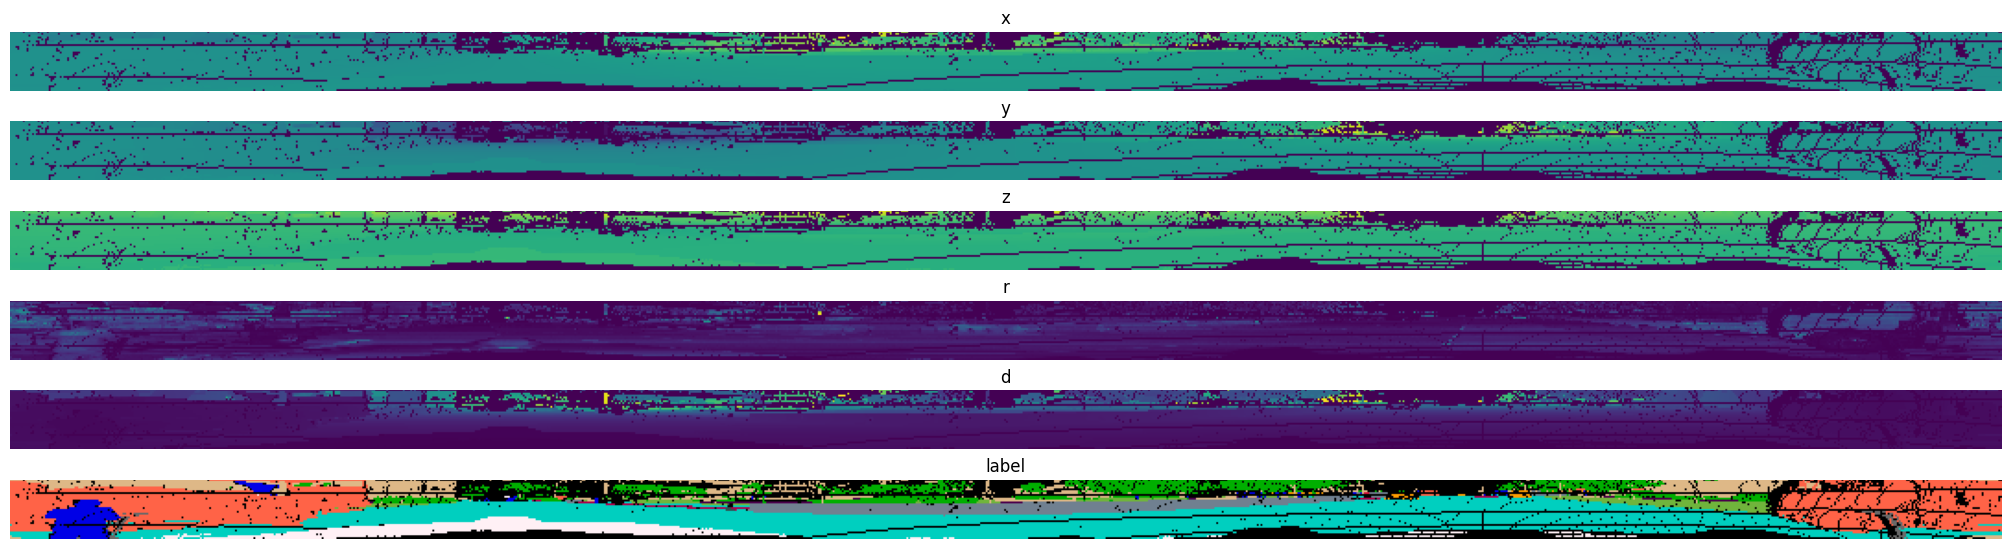

In [ ]:
#| eval: false
proj = SphericalProjection(fov_up_deg=10., fov_down_deg=-30., W=1080, H=32) # these values were taken from [https://www.nuscenes.org/nuscenes#data-collection]
scaling_values = {
    "x" : {"min": -100., "max":100.},
    "y" : {"min": -104., "max":102.},
    "z" : {"min": -31., "max":18.},
    "r" : {"min": 0., "max":1.},
    "d" : {"min": 0., "max":105.}
}
tfms = v2.Compose([
    ProjectionTransform(proj),
    ProjectionVizTransform(ds.color_map_rgb_np, ds.learning_map_inv_np, scaling_values),
])
ds.set_transform(tfms)
item = ds[2]
img = item['frame']
label = item['label']

plot_projections(img, label, ['x', 'y', 'z', 'r', 'd'])

After experimenting with the dataset, the scale values in the table below were found to produce reasonable results.

| Feature   | Min     | Max    |
|-----------|---------|--------|
| **x**     | -100.0  | 100.0  |
| **y**     | -104.0  | 102.0  |
| **z**     | -31.0   | 18.0    |
| **r**     | 0.0     | 1.0    |
| **d**     | 0.0     | 105.0  |

### Unfolding Projection

Explained in the `UnfoldingProjection` documentation.

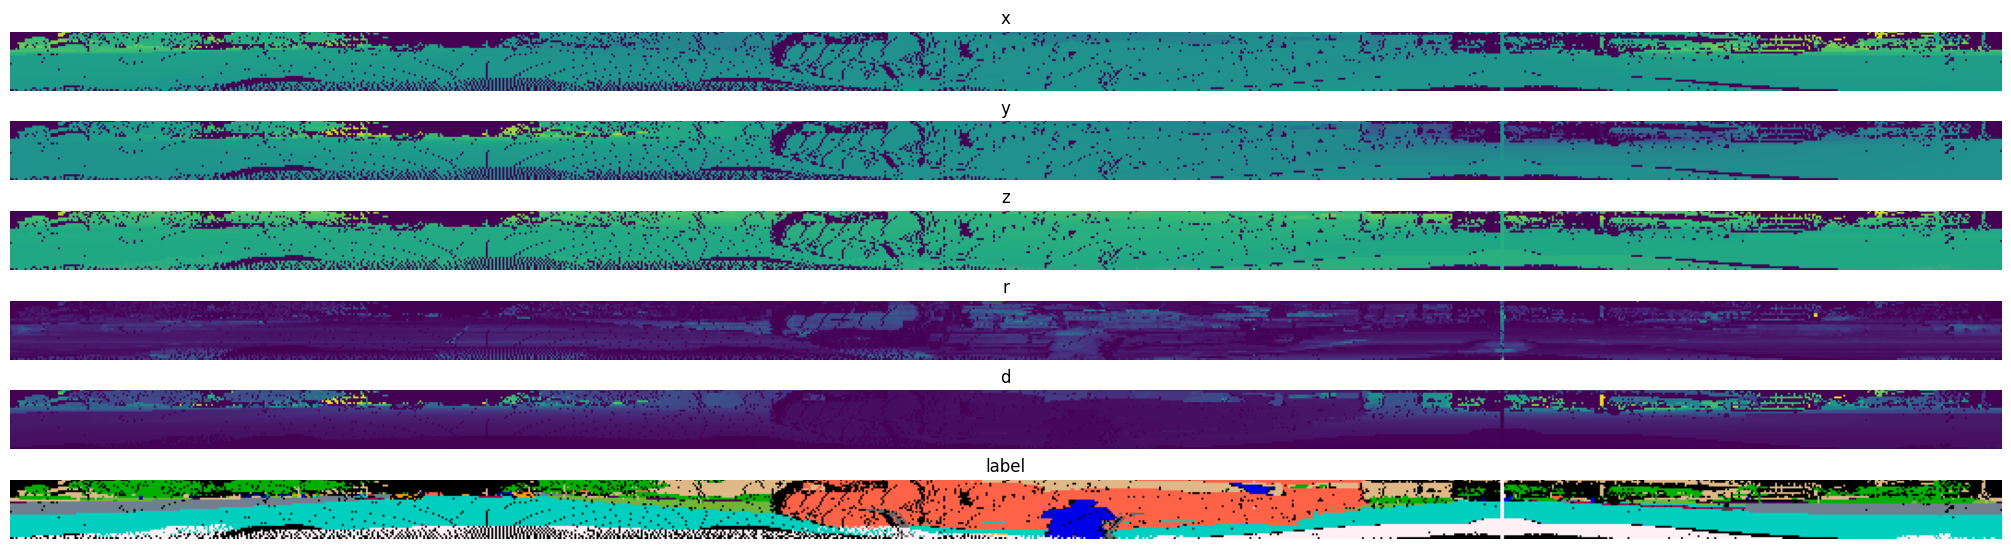

In [ ]:
#| eval: false
proj = UnfoldingProjection(W=1080, H=32)
scaling_values = {
    "x" : {"min": -100., "max":100.},
    "y" : {"min": -104., "max":102.},
    "z" : {"min": -31., "max":18.},
    "r" : {"min": 0., "max":1.},
    "d" : {"min": 0., "max":105.}
}
tfms = v2.Compose([
    ProjectionTransform(proj),
    ProjectionVizTransform(ds.color_map_rgb_np, ds.learning_map_inv_np, scaling_values),
])
ds.set_transform(tfms)
item = ds[2]
img = item['frame']
label = item['label']

plot_projections(img, label, ['x', 'y', 'z', 'r', 'd'])

# Dataset as a PyTorch Dataset

Dataset as a `torch.tensor` object is already explained in the `SemanticKITTIDataset` documentation.

In [ ]:
#| eval: false
proj = SphericalProjection(fov_up_deg=10., fov_down_deg=-30., W=1080, H=32)
tfms = v2.Compose([
    ProjectionTransform(proj),
    ProjectionToTensorTransform(),
])
ds.set_transform(tfms)

item = ds[128]
img = item['frame']
label = item['label']
mask = item['mask']

print(img.shape, img.type())
print(label.shape, label.type())
print(mask.shape, mask.type())

torch.Size([5, 32, 1080]) torch.FloatTensor
torch.Size([32, 1080]) torch.LongTensor
torch.Size([32, 1080]) torch.BoolTensor


In [ ]:
#| eval: false
bs = 1
dl = DataLoader(ds, bs, num_workers=8)
for batch in dl:
    item = batch
    img = item['frame']
    label = item['label']
    mask = item['mask']
    print(f"Shape of img \t [N, C, H, W]: \t {img.shape}")
    print(f"Shape of label \t [N, H, W]: \t {label.shape}")
    print(f"Shape of mask \t [N, H, W]: \t {mask.shape}")
    break

Shape of img 	 [N, C, H, W]: 	 torch.Size([1, 5, 32, 1080])
Shape of label 	 [N, H, W]: 	 torch.Size([1, 32, 1080])
Shape of mask 	 [N, H, W]: 	 torch.Size([1, 32, 1080])


# Detection Dataset

In [ ]:
class NuScenesLidarDetDataset(Dataset):
    """
    PyTorch Dataset for loading nuScenes LIDAR_TOP point cloud data and detection bounding boxes with labels.
    Handles transformation of bounding boxes from global to lidar frame and provides category/color mappings.
    """
    @staticmethod
    def transform_box_global_to_lidar(box: dict, # dict with 'translation', 'size', 'rotation' (quaternion [w, x, y, z])
                                      ego_pose: dict, # dict with 'translation', 'rotation' (quaternion [w, x, y, z])
                                      calib_sensor: dict # dict with 'translation', 'rotation' (quaternion [w, x, y, z]
                                    ) -> np.ndarray: # Array of shape [center_x, center_y, center_z, width, length, height, yaw]
        "Transform a bounding box from global coordinates to the lidar sensor frame."
        # Extract box center and rotation
        box_center = np.array(box['translation'])
        box_quat = Quaternion(box['rotation'])
        ego_translation = np.array(ego_pose['translation'])
        ego_quat = Quaternion(ego_pose['rotation'])
        # Transform center to ego frame
        center_ego = np.dot(ego_quat.inverse.rotation_matrix, box_center - ego_translation)
        quat_ego = ego_quat.inverse * box_quat
        # Transform center to lidar frame
        calib_translation = np.array(calib_sensor['translation'])
        calib_quat = Quaternion(calib_sensor['rotation'])
        center_lidar = np.dot(calib_quat.inverse.rotation_matrix, center_ego - calib_translation)
        quat_lidar = calib_quat.inverse * quat_ego
        w_q, x_q, y_q, z_q = quat_lidar.elements
        yaw = np.arctan2(2.0 * (w_q*z_q + x_q*y_q), 1.0 - 2.0 * (y_q*y_q + z_q*z_q))
        size = np.array(box['size'])
        return np.array([center_lidar[0], center_lidar[1], center_lidar[2], size[0], size[1], size[2], yaw], dtype=np.float32)

    def __init__(self,
                 data_path: str, # Root directory containing the nuScenes dataset files.
                 version: str, # Dataset version to use (e.g., 'v1.0-mini').
                 split: str = 'train', #  Dataset split — 'train', 'val', or 'test'.
                 transform: callable = None # An optional transform function applied to each data sample.
                 ):
        "Initialize the dataset by loading metadata and preparing mappings."
        self.data_path = Path(data_path)
        self.version = version
        self.split = split
        self.transform = transform

        # Load metadata files from nuScenes dataset
        with open(self.data_path / self.version / 'sample_data.json') as f:
            sample_data = json.load(f)
        with open(self.data_path / self.version / 'sample.json') as f:
            self.samples = {s['token']: s for s in json.load(f)}
        with open(self.data_path / self.version / 'sample_annotation.json') as f:
            self.annotations = json.load(f)
        with open(self.data_path / self.version / 'instance.json') as f:
            self.instances = {inst['token']: inst for inst in json.load(f)}
        with open(self.data_path / self.version / 'category.json') as f:
            self.category = json.load(f)
        with open(self.data_path / self.version / 'colors.json') as f:
            self.color_map = json.load(f)
        with open(self.data_path / self.version / 'ego_pose.json') as f:
            self.ego_poses = {e['token']: e for e in json.load(f)}
        with open(self.data_path / self.version / 'calibrated_sensor.json') as f:
            self.calibrated_sensors = {c['token']: c for c in json.load(f)}

        # Build category token to index and name mappings
        self.category_token_to_index = {cat['token']: cat['index'] for cat in self.category}
        self.category_token_to_name = {cat['token']: cat['name'] for cat in self.category}
            
        # Create color map array for visualization
        self.color_map_rgb_np = np.zeros((len(self.category), 3), dtype=np.uint8)
        for category in self.category:
            index = category['index']
            name = category['name']
            if name in self.color_map:
                self.color_map_rgb_np[index] = self.color_map[name]

        # Create mapping from sample_data token to sample token
        self.sample_data_to_sample = {sd['token']: sd['sample_token'] for sd in sample_data}
        
        # Create mapping from sample token to annotations
        self.sample_to_annotations = {}
        for ann in self.annotations:
            sample_token = ann['sample_token']
            if sample_token not in self.sample_to_annotations:
                self.sample_to_annotations[sample_token] = []
            self.sample_to_annotations[sample_token].append(ann)

        # Get LIDAR_TOP sample entries
        self.lidar_entries = [
            entry for entry in sample_data
            if 'LIDAR' in entry['filename']
        ]

        # Create category name to index and index to name mappings
        self.category_name_to_index = {cat['name']: cat['index'] for cat in self.category}
        self.category_index_to_name = {cat['index']: cat['name'] for cat in self.category}

        # Build learning_map_np and content_weights similar to SemanticKITTI
        self.learning_map_np = np.arange(256, dtype=np.uint32)
        self.learning_map_inv_np = np.arange(256, dtype=np.uint32)
        self.content_weights = np.ones(256, dtype=np.float32)

        self.is_test = (split == 'test')

    def set_transform(self,
                      transform: callable): # The transform function to apply.	
        "Set a transform to be applied to each sample."
        self.transform = transform

    def __len__(self):
        "Return the number of lidar entries in the dataset."
        return len(self.lidar_entries)

    def __getitem__(self,
                    idx: int # Index of the sample to retrieve.
                    ) -> dict: # A dictionary containing the sample data in the format:
        """
        Retrieve a sample from the dataset.
        It returns a dictionary with the following keys:
            - 'frame': Point cloud data (N, 5) where N is the number of points.
            - 'boxes': Bounding boxes in lidar frame (N, 7) where each box is [x, y, z, width, length, height, yaw].
            - 'labels': Labels for each bounding box (N,) as category indices.
            - 'token': Sample data token.
            - 'sample_token': Sample token corresponding to the sample data.
        """
        entry = self.lidar_entries[idx]
        token = entry['token']
        sample_token = self.sample_data_to_sample.get(token)

        # Load point cloud from binary file
        lidar_path = self.data_path / entry['filename']
        frame = np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 5)  # (N, 5)

        # Normalize intensity (divide by 255)
        frame[:, 3] /= 255.0

        boxes = []
        labels = []

        # Get ego_pose and calibrated_sensor for this sample_data
        ego_pose = self.ego_poses[entry['ego_pose_token']]
        calib_sensor = self.calibrated_sensors[entry['calibrated_sensor_token']]

        # Get annotations for this sample (skip if test split)
        if not self.is_test and sample_token in self.sample_to_annotations:
            annotations = self.sample_to_annotations[sample_token]
            
            for ann in annotations:
                # Transform box from global to lidar frame
                box = NuScenesLidarDetDataset.transform_box_global_to_lidar(ann, ego_pose, calib_sensor)
                
                # Get category index from instance
                instance_token = ann['instance_token']
                instance = self.instances.get(instance_token)
                if instance is not None:
                    category_token = instance['category_token']
                    label = self.category_token_to_index.get(category_token, 0)
                else:
                    label = 0  # fallback
                
                boxes.append(box)
                labels.append(label)
        
        # Convert boxes and labels to numpy arrays
        if len(boxes) > 0:
            boxes = np.array(boxes, dtype=np.float32)
            labels = np.array(labels, dtype=np.int64)
        else:
            boxes = np.zeros((0, 7), dtype=np.float32)
            labels = np.zeros(0, dtype=np.int64)
        
        # Build sample item dictionary
        item = {
            'frame': frame,
            'boxes': boxes,
            'labels': labels,
            'token': token,
            'sample_token': sample_token
        }

        if self.transform:
            item = self.transform(item)

        return item

In [ ]:
#| eval: false
# Path to the nuScenes mini dataset
data_path = '../../mini-dataset'

# Create dataset instance
ds = NuScenesLidarDetDataset(data_path, 'v1.0-mini')
print(f"Dataset size: {len(ds)}")

Dataset size: 3935


In [ ]:
#| eval: false
item = ds[128]
frame = item['frame']
frame, frame.shape

(array([[-2.7697976e+00, -2.6218906e-01, -1.6518306e+00,  1.2941177e-01,
          0.0000000e+00],
        [-2.8876700e+00, -2.6031393e-01, -1.6314029e+00,  1.3333334e-01,
          1.0000000e+00],
        [-3.0022368e+00, -2.5890714e-01, -1.6049888e+00,  1.1764706e-01,
          2.0000000e+00],
        ...,
        [-3.7035980e+00, -6.4640562e-03,  5.2050740e-01,  1.4509805e-01,
          2.9000000e+01],
        [-1.2295158e+01, -1.7167287e-02,  2.0200222e+00,  1.1764706e-02,
          3.0000000e+01],
        [-2.6788683e+00, -3.2744890e-03,  5.0472456e-01,  4.3137256e-02,
          3.1000000e+01]], dtype=float32),
 (34720, 5))

In [ ]:
#| eval: false
# Get a sample
item = ds[128]

# Print the data
print(f"Frame shape: {item['frame'].shape}, dtype: {item['frame'].dtype}")
print(f"Boxes shape: {item['boxes'].shape}")
print(f"Labels shape: {item['labels'].shape}")
print(f"Token: {item['token']}")
print(f"Sample token: {item['sample_token']}")

Frame shape: (34720, 5), dtype: float32
Boxes shape: (137, 7)
Labels shape: (137,)
Token: e217ad754152441783166ca80cbb6d5e
Sample token: 1e3d79dae62742a0ad64c91679863358


In [ ]:
#| export
class LidarVisualizer:
    "A utility class for visualizing LIDAR point clouds and 3D bounding boxes using [Polyscope](https://polyscope.run/)."
    @staticmethod
    def create_box_lines(box: np.ndarray # [center_x, center_y, center_z, width, length, height, rotation_z]
                         )-> tuple: # (corners: (8, 3) array of 3D coordinates of the 8 box corners in global space, lines: (12, 2) array of edge index pairs representing box edges for rendering.)
        "Create 3D bounding box lines from box parameters."
        cx, cy, cz, w, l, h, rot_z = box
        # 8 corners in local box frame - NuScenes convention:
        # x-axis points forward, y-axis points left, z-axis points up
        # width (w) is along y-axis, length (l) is along x-axis, height (h) is along z-axis
        x_corners = np.array([l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2])
        y_corners = np.array([w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2])
        z_corners = np.array([h/2, h/2, h/2, h/2, -h/2, -h/2, -h/2, -h/2])
        # Rotation (NuScenes rotates around z-axis, but need to consider right-hand rule)
        R = np.array([
            [np.cos(rot_z), -np.sin(rot_z), 0],
            [np.sin(rot_z), np.cos(rot_z), 0],
            [0, 0, 1]
        ])
        corners = np.stack([x_corners, y_corners, z_corners], axis=1)
        corners = (R @ corners.T).T + np.array([cx, cy, cz])
        # 12 lines for box edges
        lines = np.array([
            [0, 1], [1, 2], [2, 3], [3, 0],  # top face
            [4, 5], [5, 6], [6, 7], [7, 4],  # bottom face
            [0, 4], [1, 5], [2, 6], [3, 7]   # verticals
        ])
        return corners, lines

    @staticmethod
    def plot_lidar_with_boxes_polyscope(item: dict, # A dictionary representing one data sample with 'frame', 'boxes', and 'labels', typically from `NuScenesLidarDetDataset.__getitem__`
                                        color_map_rgb_np: np.ndarray = None): # Optional numpy array for label colors (shape: [num_classes, 3] with RGB values in [0, 255] range)
        "Visualizes a LIDAR frame with 3D bounding boxes in an interactive window using Polyscope. "
        frame = item['frame'].copy()  # Make a copy to avoid modifying the original
        boxes = item['boxes']
        labels = item['labels']
        
        ps.init()
        ps.set_up_dir("z_up") # Set Z as the up direction
        ps.remove_all_structures()
        ps_cloud = ps.register_point_cloud("lidar", frame[:, :3], radius=0.001)
        
        # Color by intensity if available, otherwise by height
        if frame.shape[1] > 3:
            intensity = frame[:, 3]  # Assuming 4th column is intensity
            ps_cloud.add_color_quantity("intensity", np.stack([intensity, intensity, intensity], axis=1), enabled=True)
        else:
            # Color by z (height), normalized to [0,1]
            z = frame[:, 2]
            z_min, z_max = z.min(), z.max()
            z_norm = (z - z_min) / (z_max - z_min + 1e-6)
            ps_cloud.add_color_quantity("height", np.stack([z_norm, z_norm, z_norm], axis=1), enabled=True)
        
        # Draw bounding boxes
        for i, box in enumerate(boxes):
            corners, lines = LidarVisualizer.create_box_lines(box)
            color = np.array([1, 0, 0])  # Default color: red
            if color_map_rgb_np is not None:
                label = labels[i]
                if 0 <= label < color_map_rgb_np.shape[0]:
                    color = color_map_rgb_np[label] / 255.0
            ps.register_curve_network(f"box_{i}", corners, lines, color=color, radius=0.0005)
        
        ps.show()

In [ ]:
#| eval: false
import polyscope as ps
# Visualize a sample with bounding boxes
# This will open a Polyscope window
item = ds[128]
LidarVisualizer.plot_lidar_with_boxes_polyscope(item, color_map_rgb_np=ds.color_map_rgb_np)

#| eval: false
from IPython.display import HTML
HTML('<img src="media/polyscope.gif" style="width:100%;">')

# BEV Projection

In [ ]:
#| export
class NuScenesBEVRenderer:
    """
    `NuScenesBEVRenderer` is a utility for visualizing LIDAR point cloud data and associated 3D bounding boxes in a Bird’s Eye View (BEV) using Matplotlib. It is specifically tailored for use with the nuScenes dataset, following its box conventions for position and orientation.
    The orientation and BEV projection logic in this implementation is adapted from the official [nuScenes devkit](https://github.com/nutonomy/nuscenes-devkit).
    """

    def __init__(self,
                 x_lim: tuple = (-50, 50), # x-axis limits for the BEV plot
                 y_lim: tuple = (-50, 50), # y-axis limits for the BEV plot
                 marker_size: float = 0.2, # Size of the LIDAR points in the BEV plot
                 show_boxes: bool = True, # Whether to draw bounding boxes on the BEV plot
                 show_labels: bool = False, # Whether to show labels on the bounding boxes
                 figsize: tuple = (8, 8)): # Size of the BEV plot figure
        self.x_lim = x_lim
        self.y_lim = y_lim
        self.marker_size = marker_size
        self.show_boxes = show_boxes
        self.show_labels = show_labels
        self.figsize = figsize

    def render(self,
               item: dict, # A dictionary representing one data sample with 'frame', 'boxes', and 'labels', typically from `NuScenesLidarDetDataset.__getitem__`
               color_map_rgb: np.ndarray, # A numpy array for label colors (shape: [num_classes, 3] with RGB values in [0, 255] range)
               category_index_to_name: dict): # A dictionary mapping category indices to names (optional, for labeling boxes)
        "This method plots the LIDAR points in BEV and overlays 2D projections of the 3D bounding boxes."

        frame = item['frame']
        boxes = item['boxes']
        labels = item['labels']

        fig, ax = plt.subplots(figsize=self.figsize)
        ax.set_xlim(self.x_lim)
        ax.set_ylim(self.y_lim)
        ax.set_aspect('equal')

        # Plot LIDAR points
        points_xy = frame[:, :2]
        heights = frame[:, 2]
        ax.scatter(points_xy[:, 0], points_xy[:, 1], c=heights, cmap='viridis', s=self.marker_size, alpha=0.8)

        # Draw bounding boxes
        if self.show_boxes and len(boxes) > 0:
            for box, label in zip(boxes, labels):
                self._draw_box(ax, box, color_map_rgb[label], category_index_to_name.get(label, "unknown"), self.show_labels)


        # remove axis
        ax.axis('off')
        plt.show()

    def _draw_box(self,
                  ax: Axes, # The matplotlib Axes object to draw on
                  box: np.ndarray, # A bounding box in the format [center_x, center_y, center_z, width, length, height, yaw]
                  color: np.ndarray, # RGB color for the box (shape: [3] with values in [0, 255])
                  label: str, # Label for the box (optional, can be used for text annotation)
                  show_label: bool = False): # Whether to show the label text on the box
        "Draw a 2D bounding box using NuScenes box convention: (x, y, z, width, length, height, yaw)"

        cx, cy, _, w, l, _, yaw = box

        # Box corners in local frame (length = x, width = y)
        x_corners = np.array([l/2, l/2, -l/2, -l/2])
        y_corners = np.array([w/2, -w/2, -w/2, w/2])
        corners = np.stack((x_corners, y_corners), axis=1)

        # Rotation
        rot = np.array([
            [np.cos(yaw), -np.sin(yaw)],
            [np.sin(yaw),  np.cos(yaw)]
        ])
        rotated = corners @ rot.T
        translated = rotated + np.array([cx, cy])

        # Draw box
        poly = Polygon(translated, closed=True, edgecolor=color / 255.0, facecolor='none', linewidth=1.5)
        ax.add_patch(poly)

        if show_label:
            ax.text(cx, cy, label, color=color / 255.0, fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))

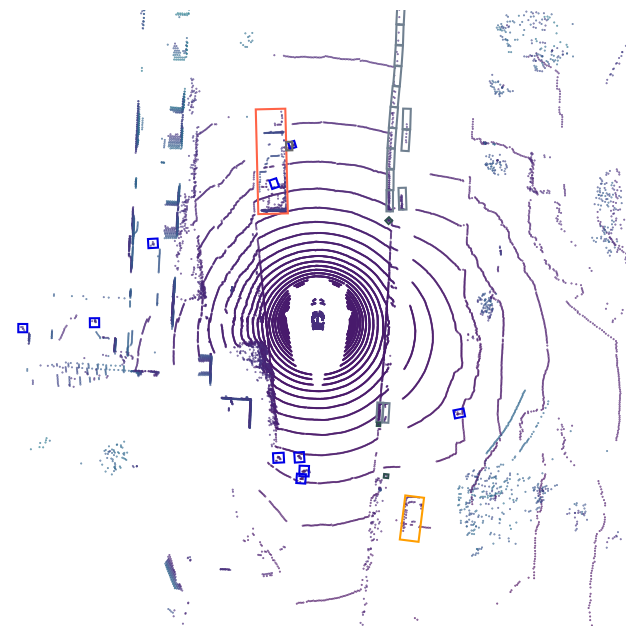

In [ ]:
#| eval: false
sample = ds[0]

renderer = NuScenesBEVRenderer(x_lim=(-30, 30), y_lim=(-30, 30))
renderer.render(sample, ds.color_map_rgb_np, ds.category_index_to_name)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()